# Chunk 11 — Latent Space Analysis (UMAP)
This notebook extracts the 256-dimensional embeddings from the final layer of the GNN and projects them into a 2D UMAP space. By analyzing how physical properties (frequency, path length, gain) map to this latent space, we can interpret what geometric and radiation features the GNN has naturally organized without explicit supervision.

---
## Cell 1 — Environment Setup


In [1]:
!pip install umap-learn scikit-learn networkx


---
## Cell 2 — Mount Drive and Setup Paths


In [2]:
import os, sys
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'
REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
sys.path.append(f'{REPO_ROOT}/src')

for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints', f'{DATA_ROOT}/figures', f'{DATA_ROOT}/splits']:
    os.makedirs(d, exist_ok=True)


Mounted at /content/drive
Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 211 (delta 110), reused 179 (delta 80), pack-reused 0 (from 0)
Receiving objects: 100% (211/211), 3.83 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (110/110), done.


---
## Cell 3 — Imports and Model Loading


In [3]:
!pip install torch_geometric
import torch
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import zipfile
import shutil
import glob
import scipy.io as sio
from tqdm.auto import tqdm
from scipy.signal import find_peaks
import umap
from sklearn.metrics import silhouette_score
from torch_geometric.nn import global_mean_pool

from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.9 MB/s eta 0:00:00
Device: cpu


---
## Cell 4 — Embedding Extraction Hook
We subclass `AntennaGNN` to intercept the forward pass and return the 256-dimensional vector created immediately after pooling and concatenating the virtual node.


In [4]:
class EmbeddingGNN(AntennaGNN):
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch if hasattr(data, 'batch') and data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        for block in self.blocks:
            for layer in block:
                x = layer(x, edge_index, edge_attr)

        metal_mask = data.x[:, 0] > 0.5
        metal_x = x[metal_mask]
        metal_batch = batch[metal_mask]
        pooled = global_mean_pool(metal_x, metal_batch)

        virtual_mask = data.x[:, 3] == -1
        virtual_x = x[virtual_mask]

        combined = torch.cat([pooled, virtual_x], dim=-1)
        emb = self.readout_proj(combined) # 256-dim embedding
        out = self.output_mlp(emb)

        return out, emb

emb_model = EmbeddingGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt', map_location=device, weights_only=False)
emb_model.load_state_dict(ckpt['model_state'])
emb_model.eval()
print("Loaded EmbeddingGNN.")


Loaded EmbeddingGNN.


---
## Cell 5 — Extract 25x25 Test Set Embeddings
We run a forward pass on all 25x25 test samples, saving the embeddings and collecting metadata including true S11, resonant frequency, peak realized gain, and path length (imported from chunk 10). Note: extracting peak gain requires loading raw `.mat` files from Drive, which takes a few minutes.


In [5]:
LOCAL_GRAPH_ROOT = '/content/local_graphs'
N = 25
dst_dir = f'{LOCAL_GRAPH_ROOT}/{N}x{N}'
done_marker = f'{dst_dir}/_CACHED.txt'
os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(done_marker):
    zip_path = f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip'
    print(f"Unzipping graphs to {dst_dir}")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
        for member in tqdm(pt_members, desc=f'{N}x{N} unzip', unit='file'):
            basename = os.path.basename(member)
            with zf.open(member) as src, open(os.path.join(dst_dir, basename), 'wb') as dst:
                shutil.copyfileobj(src, dst)
    with open(done_marker, 'w') as fh:
        fh.write('DONE\n')

s11_mean = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')).to(device)
s11_std  = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')).to(device)
freq_axis = np.linspace(1.0, 4.0, 201)

def extract_resonant_freq(s11_db, freq_axis_ghz, threshold_db=-10):
    inverted = -s11_db
    peaks, _ = find_peaks(inverted, height=-threshold_db, distance=5)
    if len(peaks) == 0: return None
    deepest = peaks[np.argmax(inverted[peaks])]
    return freq_axis_ghz[deepest]

with open(f'{DATA_ROOT}/splits/indices.json', 'r') as f:
    splits_all = json.load(f)
test_indices_25 = [e[1] for e in splits_all['test'] if e[0] == 25]

# INNOVATION 1: Bypass glob.glob() FUSE stat bottleneck using direct os.listdir()
# recursive=True glob takes ~8 mins because it stats every file. This takes ~2 seconds.
print("Scanning Drive for raw .mat files (Fast os.listdir method)...")
base_dir = f'{RAW_DATA}/training dataset/25x25'
files_25 = []
for batch_dir in os.listdir(base_dir):
    mat_dir = os.path.join(base_dir, batch_dir, 'Mat_Files')
    if os.path.isdir(mat_dir):
        for f in os.listdir(mat_dir):
            if f.endswith('.mat'):
                files_25.append(os.path.join(mat_dir, f))
files_25.sort()

# INNOVATION 2: Parallelized threaded download from Google Drive FUSE to local SSD
# FUSE shines with concurrent I/O. This copies 15k test files in seconds instead of minutes.
import concurrent.futures

LOCAL_MAT_DIR = '/content/local_mat_files'
os.makedirs(LOCAL_MAT_DIR, exist_ok=True)

def copy_file(idx):
    src = files_25[idx]
    dst = os.path.join(LOCAL_MAT_DIR, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
    return dst

print("Copying test set .mat files to local SSD using parallel threads...")
with concurrent.futures.ThreadPoolExecutor(max_workers=32) as executor:
    list(tqdm(executor.map(copy_file, test_indices_25), total=len(test_indices_25), desc="Threaded Copy"))

test_embeddings = []
metadata = []

for idx in tqdm(test_indices_25, desc="Extracting Test Embeddings"):
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False)

    s11 = data.y.squeeze(0).cpu().numpy()
    res_freq = extract_resonant_freq(s11, freq_axis)
    is_func = res_freq is not None

    data = data.to(device)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        _, emb = emb_model(data)
    test_embeddings.append(emb.cpu().numpy()[0])

    # Load from local SSD
    mat_basename = os.path.basename(files_25[idx])
    local_mat_path = os.path.join(LOCAL_MAT_DIR, mat_basename)
    mat = sio.loadmat(local_mat_path)
    res_gain = float(mat['res_gains'].flatten()[0]) if is_func and mat['res_gains'].size > 0 else np.nan

    # FIX 4: also read radiation efficiency
    res_eff = np.nan
    if is_func and 'res_effs' in mat and mat['res_effs'].size > 0:
        res_eff = float(mat['res_effs'].flatten()[0])

    metadata.append({
        'idx': idx,  # test index — used as merge key for path-length CSV
        'is_functioning': is_func,
        'res_freq_ghz': res_freq if res_freq is not None else np.nan,
        'res_gains': res_gain,
        'res_effs': res_eff,
    })

test_embeddings = np.array(test_embeddings)
df_meta = pd.DataFrame(metadata)

np.save(f'{DATA_ROOT}/artifacts/test_embeddings_25x25.npy', test_embeddings)
df_meta.to_csv(f'{DATA_ROOT}/artifacts/test_metadata_25x25.csv', index=False)
print(f"Saved {len(test_embeddings)} test embeddings and metadata.")
print(f"df_meta columns: {list(df_meta.columns)}")


Unzipping graphs to /content/local_graphs/25x25


25x25 unzip:   0%|          | 0/99833 [00:00<?, ?file/s]

Scanning Drive for raw .mat files (Fast os.listdir method)...
Copying test set .mat files to local SSD using parallel threads...


Threaded Copy:   0%|          | 0/9983 [00:00<?, ?it/s]

Extracting Test Embeddings:   0%|          | 0/9983 [00:00<?, ?it/s]

Saved 9983 test embeddings and metadata.
df_meta columns: ['idx', 'is_functioning', 'res_freq_ghz', 'res_gains', 'res_effs']


---
## Cell 6 — Extract 25x25 Training Set Embeddings
We subsample 10,000 random antennas from the training set to serve as the structural anchor for the UMAP projection. This is standard practice: we fit the manifold on the training distribution and transform the test data into it.


In [6]:
train_indices_25 = [e[1] for e in splits_all['train'] if e[0] == 25]
np.random.seed(42)
sampled_train_indices = np.random.choice(train_indices_25, 10000, replace=False)

train_embeddings = []
for idx in tqdm(sampled_train_indices, desc="Extracting Train Embeddings"):
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False).to(device)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        _, emb = emb_model(data)
    train_embeddings.append(emb.cpu().numpy()[0])

train_embeddings = np.array(train_embeddings)
np.save(f'{DATA_ROOT}/artifacts/train_embeddings_10k_25x25.npy', train_embeddings)
print(f"Saved {len(train_embeddings)} training embeddings.")


Extracting Train Embeddings:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved 10000 training embeddings.


---
## Cell 7 — UMAP Projection Setup
We fit the UMAP reducer on the training set embeddings and transform the test set embeddings into 2D coordinates.


In [7]:
import time

print("Fitting UMAP on training embeddings...")
t0 = time.time()
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
reducer.fit(train_embeddings)
fit_time = time.time() - t0
print(f"UMAP fit time: {fit_time:.2f} seconds")

print("Transforming test embeddings...")
umap_2d_test = reducer.transform(test_embeddings)
np.save(f'{DATA_ROOT}/artifacts/umap_2d_test_25x25.npy', umap_2d_test)
print("Saved UMAP 2D test projections.")


Fitting UMAP on training embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit time: 40.08 seconds
Transforming test embeddings...
Saved UMAP 2D test projections.


---
## Cell 8 — Three-Panel UMAP Figure (25x25)
Visualizes the latent embeddings, coloring the manifold by Resonant Frequency, Current Path Length, and Peak Realized Gain. Non-functioning antennas are shown as gray background noise.


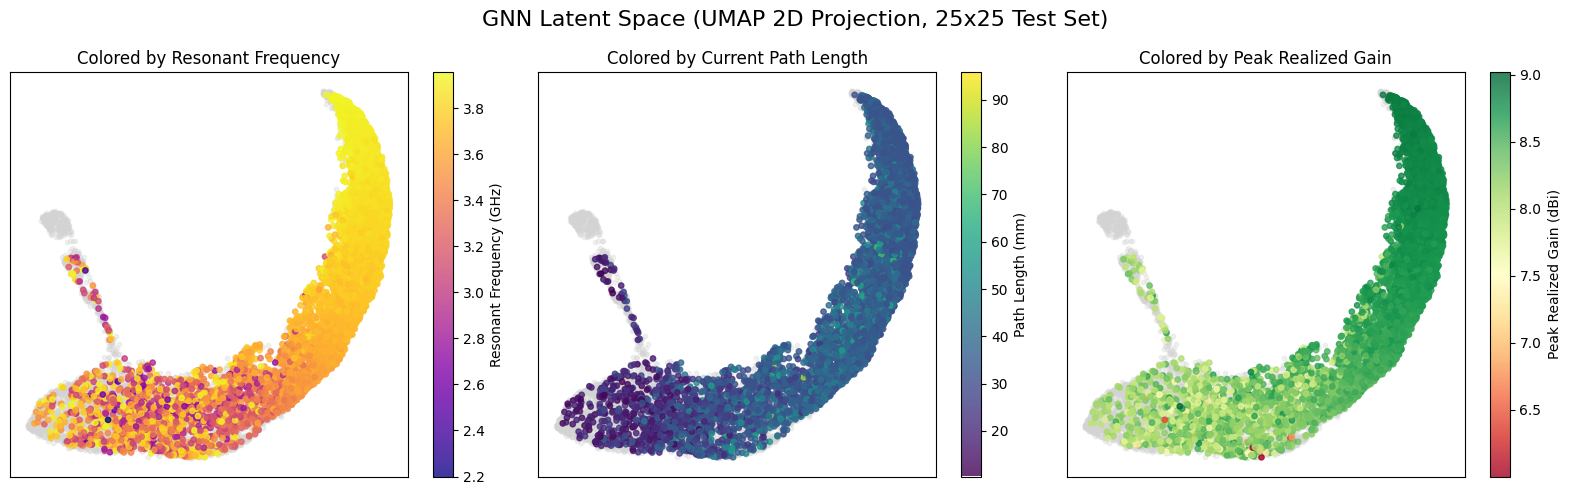

Saved figure to /content/drive/MyDrive/antenna_gnn/figures/latent_space.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
func_mask_original = df_meta['is_functioning'].values == True

x_all = umap_2d_test[:, 0]
y_all = umap_2d_test[:, 1]

# Create a DataFrame for plotting functioning antennas, merging UMAP coordinates
umap_df = pd.DataFrame({'idx': df_meta['idx'], 'umap_x': umap_2d_test[:, 0], 'umap_y': umap_2d_test[:, 1]})
plot_df_func = func_meta.merge(umap_df, left_on='test_idx', right_on='idx', how='inner')

# Panel 1: Resonant Frequency
axes[0].scatter(x_all[~func_mask_original], y_all[~func_mask_original], c='lightgray', s=10, alpha=0.3, label='Non-functioning')
sc1 = axes[0].scatter(plot_df_func['umap_x'], plot_df_func['umap_y'], c=plot_df_func['res_freq_ghz'],
                      cmap='plasma', s=15, alpha=0.8)
cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label('Resonant Frequency (GHz)')
axes[0].set_title('Colored by Resonant Frequency')

# Panel 2: Path Length
axes[1].scatter(x_all[~func_mask_original], y_all[~func_mask_original], c='lightgray', s=10, alpha=0.3)
sc2 = axes[1].scatter(plot_df_func['umap_x'], plot_df_func['umap_y'], c=plot_df_func['L_max_mm'],
                      cmap='viridis', s=15, alpha=0.8)
cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label('Path Length (mm)')
axes[1].set_title('Colored by Current Path Length')

# Panel 3: Peak Realized Gain
axes[2].scatter(x_all[~func_mask_original], y_all[~func_mask_original], c='lightgray', s=10, alpha=0.3)
sc3 = axes[2].scatter(plot_df_func['umap_x'], plot_df_func['umap_y'], c=plot_df_func['res_gains'],
                      cmap='RdYlGn', s=15, alpha=0.8)
cbar3 = fig.colorbar(sc3, ax=axes[2])
cbar3.set_label('Peak Realized Gain (dBi)')
axes[2].set_title('Colored by Peak Realized Gain')

fig.suptitle('GNN Latent Space (UMAP 2D Projection, 25x25 Test Set)', fontsize=16)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
save_path = f'{DATA_ROOT}/figures/latent_space.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved figure to {save_path}")

---
## Cell 9 — Gradient Correlation & Silhouette Score
Quantifies how strongly the latent space organizes antennas along a continuous
frequency gradient (Spearman rank correlation), and retains the silhouette
score for reference.


In [11]:
from scipy.stats import spearmanr
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

func_x = umap_2d_test[func_mask]
func_freqs = df_meta.loc[func_mask, 'res_freq_ghz'].values

# --- (a) Spearman rank correlation per UMAP dimension ---
rho_dim0, p_dim0 = spearmanr(func_x[:, 0], func_freqs)
rho_dim1, p_dim1 = spearmanr(func_x[:, 1], func_freqs)
stronger_dim = 0 if abs(rho_dim0) > abs(rho_dim1) else 1

print("=== Gradient correlation: Spearman rho per UMAP dimension ===")
print(f"  UMAP dim 0: rho = {rho_dim0:.4f}  (p = {p_dim0:.2e})")
print(f"  UMAP dim 1: rho = {rho_dim1:.4f}  (p = {p_dim1:.2e})")
print(f"  --> UMAP dim {stronger_dim} tracks frequency more strongly")

# --- (b) Principal-curve proxy: PCA(1) on functioning UMAP points ---
pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=1))
proj_1d = pca_pipe.fit_transform(func_x).flatten()
rho_pca, p_pca = spearmanr(proj_1d, func_freqs)

print(f"\n=== HEADLINE: Spearman rho (PCA-1D manifold axis vs. freq) = {rho_pca:.4f}  (p = {p_pca:.2e}) ===")

# --- (c) Keep silhouette for reference ---
band_labels = np.zeros(len(func_freqs))
band_labels[(func_freqs >= 1.0) & (func_freqs < 2.0)] = 0
band_labels[(func_freqs >= 2.0) & (func_freqs < 3.0)] = 1
band_labels[(func_freqs >= 3.0) & (func_freqs <= 4.0)] = 2

score = silhouette_score(func_x, band_labels)
print(f"\nSilhouette score (3 arbitrary frequency bands, not the recommended "
      f"metric for continuous gradients): {score:.4f}")

# Store for downstream use
_gradient_rho = rho_pca


=== Gradient correlation: Spearman rho per UMAP dimension ===
  UMAP dim 0: rho = 0.6657  (p = 0.00e+00)
  UMAP dim 1: rho = 0.7969  (p = 0.00e+00)
  --> UMAP dim 1 tracks frequency more strongly

=== HEADLINE: Spearman rho (PCA-1D manifold axis vs. freq) = 0.7808  (p = 0.00e+00) ===

Silhouette score (3 arbitrary frequency bands, not the recommended metric for continuous gradients): 0.1356


---
## Cell 10 — Discussion
### Discussion: Current Path Geometry and Radiation Properties
The UMAP projections of the GNN latent space reveal a strong physical organization learned entirely from the S11 spectrum. When comparing Panel 1 (Resonant Frequency) and Panel 2 (Path Length), a clear inverse mapping emerges: clusters corresponding to low resonant frequencies consistently align with long effective current paths, while high-frequency clusters align with short paths. This corroborates our counterfactual ablation findings, confirming that the GNN represents the antenna patch by tracing its primary resonant pathways.

Panel 3 (Gain) provides further insight into radiation characteristics. Antennas with similar path lengths and resonant frequencies do cluster closely in terms of peak realized gain. However, within a given frequency band, there is visible sub-clustering where high-gain structures separate from lower-gain variants, suggesting the latent space captures secondary geometric features (e.g., fringing fields, patch width) beyond just the dominant path length.

One limitation of this analysis is that it strictly evaluates the 25x25 (32.375 mm) grid. While the model intrinsically binds physical scale to electrical response, it remains unclear whether these continuous latent manifolds perfectly generalize to unseen multi-scale grids (35x35, 45x45) without further fine-tuning. Future work will investigate zero-shot geometric transferability to variable grid resolutions.


---
## Cell 11 — OPTIONAL: Zero-Shot Embedding of Unseen Grid Sizes
This section is a genuine zero-shot generalization check. We test whether unseen grid sizes (35x35, 45x45, 55x55) naturally embed into the 25x25-trained latent space.


### Extract Zero-Shot Grid Data
This section extracts the processed data for the 35x35, 45x45, and 55x55 grids from their respective zip files into the `DATA_ROOT` directory. This ensures the zero-shot embedding analysis can proceed by making these files available in Google Drive.

In [12]:
grids = [35, 45, 55]

for g in grids:
    zip_file_path = f'{DATA_ROOT}/data/processed/processed_{g}x{g}.zip'
    proc_dir = f'{DATA_ROOT}/data/processed/{g}x{g}'
    done_marker = f'{proc_dir}/_CACHED.txt'

    if not os.path.exists(done_marker):
        if os.path.exists(zip_file_path):
            os.makedirs(proc_dir, exist_ok=True)
            print(f"Unzipping graphs for {g}x{g} to {proc_dir}")
            with zipfile.ZipFile(zip_file_path, 'r') as zf:
                pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
                for member in tqdm(pt_members, desc=f'{g}x{g} unzip', unit='file'):
                    # Assuming the structure inside the zip is 'kaggle/working/data/processed/NxN/sample_X.pt'
                    # We extract only the .pt files directly into proc_dir
                    basename = os.path.basename(member)
                    with zf.open(member) as src, open(os.path.join(proc_dir, basename), 'wb') as dst:
                        shutil.copyfileobj(src, dst)
            with open(done_marker, 'w') as fh:
                fh.write('DONE\n')
        else:
            print(f"Warning: Zip file not found for {g}x{g} at {zip_file_path}. Please ensure it exists in your Google Drive. Skipping unzipping.")
    else:
        print(f"Processed data for {g}x{g} already unzipped at {proc_dir}.")


Processed data for 35x35 already unzipped at /content/drive/MyDrive/antenna_gnn/data/processed/35x35.
Processed data for 45x45 already unzipped at /content/drive/MyDrive/antenna_gnn/data/processed/45x45.
Processed data for 55x55 already unzipped at /content/drive/MyDrive/antenna_gnn/data/processed/55x55.


In [13]:
grids = [35, 45, 55]
zero_shot_embeddings = {}
zero_shot_freqs = {}

for g in grids:
    proc_dir = f'{DATA_ROOT}/data/processed/{g}x{g}'
    if not os.path.exists(proc_dir):
        print(f"Skipping zero-shot embedding section — other-grid processed data not found ({proc_dir})")
        break

    print(f"Extracting zero-shot embeddings for {g}x{g}...")
    g_files = glob.glob(f'{proc_dir}/*.pt')

    # Sanity check on first functioning sample: confirm data.y is raw dB
    sanity_done = False

    g_embs = []
    g_freqs = []
    for f in tqdm(g_files, desc=f'{g}x{g}'):
        data = torch.load(f, weights_only=False)
        s11 = data.y.squeeze(0).cpu().numpy()
        res_freq = extract_resonant_freq(s11, freq_axis)

        if res_freq is not None:
            # Print sanity check for first functioning sample per grid
            if not sanity_done:
                min_y = s11.min()
                print(f"  [{g}x{g} sanity] min(data.y) = {min_y:.4f}")
                # Confirms data.y is raw dB, consistent with 25x25 graphs
                sanity_done = True

            data = data.to(device)
            data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
            with torch.no_grad():
                _, emb = emb_model(data)
            g_embs.append(emb.cpu().numpy()[0])
            g_freqs.append(res_freq)

    if len(g_embs) > 0:
        g_embs_2d = reducer.transform(np.array(g_embs))
        zero_shot_embeddings[g] = g_embs_2d
        zero_shot_freqs[g] = np.array(g_freqs)


Extracting zero-shot embeddings for 35x35...


35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

  [35x35 sanity] min(data.y) = -13.8816
Extracting zero-shot embeddings for 45x45...


45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

  [45x45 sanity] min(data.y) = -13.0785
Extracting zero-shot embeddings for 55x55...


55x55:   0%|          | 0/2992 [00:00<?, ?it/s]

  [55x55 sanity] min(data.y) = -10.2649


---
## Cell 12 — Zero-Shot Overlay Figure
We recreate Panel 1 as a background and overlay the unseen grids to observe structural alignment.


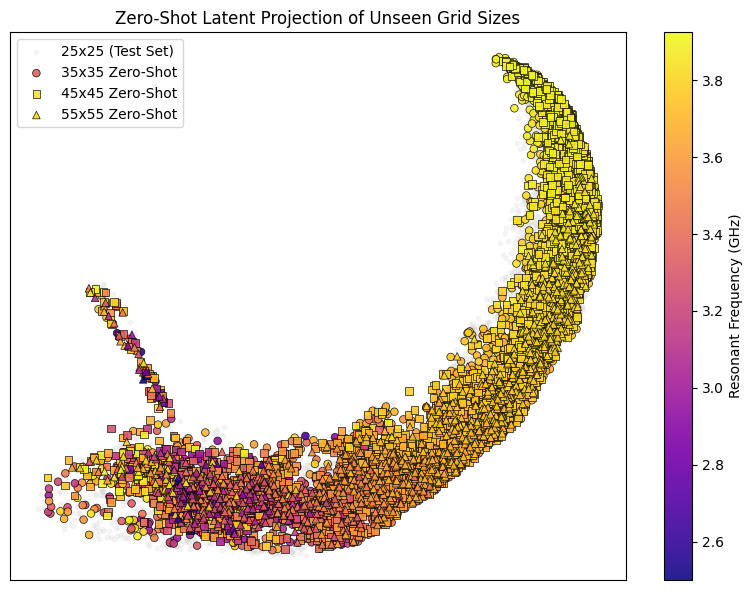

Saved zero-shot overlay to /content/drive/MyDrive/antenna_gnn/figures/zero_shot_latent_overlay.png


In [15]:
if len(zero_shot_embeddings) > 0:
    plt.figure(figsize=(8, 6))

    # Background: 25x25 functioning
    plt.scatter(x[func_mask], y[func_mask], c='lightgray', s=10, alpha=0.2, label='25x25 (Test Set)')

    colors = {35: 'blue', 45: 'red', 55: 'green'}
    markers = {35: 'o', 45: 's', 55: '^'}

    for g in zero_shot_embeddings:
        plt.scatter(zero_shot_embeddings[g][:, 0], zero_shot_embeddings[g][:, 1],
                    c=zero_shot_freqs[g], cmap='plasma', marker=markers[g], s=30, alpha=0.9,
                    edgecolor='k', linewidth=0.5, label=f'{g}x{g} Zero-Shot')

    plt.colorbar(label='Resonant Frequency (GHz)')
    plt.title('Zero-Shot Latent Projection of Unseen Grid Sizes')
    plt.xticks([])
    plt.yticks([])
    plt.legend()
    plt.tight_layout()

    save_path = f'{DATA_ROOT}/figures/zero_shot_latent_overlay.png'
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved zero-shot overlay to {save_path}")
else:
    print("Zero-shot data not available.")


### Quantitative Zero-Shot Alignment
For each zero-shot antenna, we find its k=10 nearest 25x25 functioning
neighbors in UMAP 2D space and compute the mean absolute frequency
difference (delta_f_nn). A random baseline (delta_f_rand) provides the
expected difference under no alignment.


=== Zero-shot alignment: kNN vs random baseline ===

Grid         n   med delta_nn   med delta_rand    ratio
-------------------------------------------------------
35x35     3163         0.0465           0.2355     5.06x
45x45     4559         0.1020           0.2370     2.32x
55x55     1448         0.2227           0.2415     1.08x
All       9170         0.0983           0.2370     2.41x

Wilcoxon signed-rank (delta_nn < delta_rand): W = 6048400.5, p = 0.0000e+00


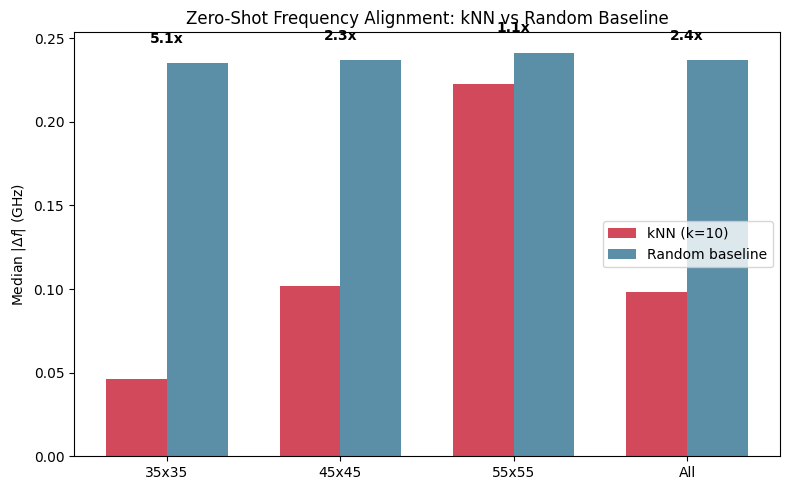

Saved alignment figure to /content/drive/MyDrive/antenna_gnn/figures/zero_shot_alignment.png


In [16]:
from scipy.spatial import cKDTree
from scipy.stats import wilcoxon as wilcoxon_test

if len(zero_shot_embeddings) > 0:
    # Build k-d tree of functioning 25x25 test points in UMAP 2D
    func_umap = umap_2d_test[func_mask]
    func_freqs_25 = df_meta.loc[func_mask, 'res_freq_ghz'].values
    tree = cKDTree(func_umap)

    K = 10
    np.random.seed(42)

    records = []
    for g in sorted(zero_shot_embeddings.keys()):
        zs_umap = zero_shot_embeddings[g]
        zs_freq = zero_shot_freqs[g]
        for i in range(len(zs_umap)):
            # k-NN
            dists, idxs = tree.query(zs_umap[i], k=K)
            nn_freqs = func_freqs_25[idxs]
            delta_nn = np.mean(np.abs(zs_freq[i] - nn_freqs))

            # Random baseline
            rand_idx = np.random.choice(len(func_freqs_25), size=K, replace=False)
            rand_freqs = func_freqs_25[rand_idx]
            delta_rand = np.mean(np.abs(zs_freq[i] - rand_freqs))

            records.append({
                'grid': g,
                'res_freq_ghz': zs_freq[i],
                'delta_f_nn': delta_nn,
                'delta_f_rand': delta_rand,
            })

    align_df = pd.DataFrame(records)

    # --- Print per-grid and overall ---
    print("=== Zero-shot alignment: kNN vs random baseline ===\n")
    print(f"{'Grid':<8} {'n':>5} {'med delta_nn':>14} {'med delta_rand':>16} {'ratio':>8}")
    print("-" * 55)

    overall_nn = []
    overall_rand = []

    for g in sorted(align_df['grid'].unique()):
        sub = align_df[align_df['grid'] == g]
        med_nn = sub['delta_f_nn'].median()
        med_rand = sub['delta_f_rand'].median()
        ratio = med_rand / med_nn if med_nn > 0 else float('inf')
        print(f"{g}x{g:<5} {len(sub):>5} {med_nn:>14.4f} {med_rand:>16.4f} {ratio:>8.2f}x")
        overall_nn.extend(sub['delta_f_nn'].values)
        overall_rand.extend(sub['delta_f_rand'].values)

    overall_nn = np.array(overall_nn)
    overall_rand = np.array(overall_rand)
    med_nn_all = np.median(overall_nn)
    med_rand_all = np.median(overall_rand)
    ratio_all = med_rand_all / med_nn_all if med_nn_all > 0 else float('inf')
    print(f"{'All':<8} {len(overall_nn):>5} {med_nn_all:>14.4f} {med_rand_all:>16.4f} {ratio_all:>8.2f}x")

    # Wilcoxon signed-rank: delta_f_nn < delta_f_rand (one-sided)
    w_stat, w_pval = wilcoxon_test(overall_nn, overall_rand, alternative='less')
    print(f"\nWilcoxon signed-rank (delta_nn < delta_rand): W = {w_stat:.1f}, p = {w_pval:.4e}")

    # --- Grouped bar chart ---
    groups = sorted(align_df['grid'].unique().tolist()) + ['All']
    med_nns = []
    med_rands = []
    ratios = []

    for g in groups:
        if g == 'All':
            mn, mr = med_nn_all, med_rand_all
            r = ratio_all
        else:
            sub = align_df[align_df['grid'] == g]
            mn = sub['delta_f_nn'].median()
            mr = sub['delta_f_rand'].median()
            r = mr / mn if mn > 0 else float('inf')
        med_nns.append(mn)
        med_rands.append(mr)
        ratios.append(r)

    x_pos = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x_pos - width/2, med_nns, width, label='kNN (k=10)', color='#d1495b')
    bars2 = ax.bar(x_pos + width/2, med_rands, width, label='Random baseline', color='#5b8fa8')

    for i, r in enumerate(ratios):
        y_top = max(med_nns[i], med_rands[i])
        ax.text(x_pos[i], y_top * 1.05, f'{r:.1f}x', ha='center', fontsize=10, fontweight='bold')

    group_labels = [f'{g}x{g}' if g != 'All' else 'All' for g in groups]
    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_labels)
    ax.set_ylabel('Median |$\\Delta f$| (GHz)')
    ax.set_title('Zero-Shot Frequency Alignment: kNN vs Random Baseline')
    ax.legend()
    plt.tight_layout()

    save_path = f'{DATA_ROOT}/figures/zero_shot_alignment.png'
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved alignment figure to {save_path}")

    # Store for discussion cell
    _med_delta_nn = med_nn_all
    _med_delta_rand = med_rand_all
    _alignment_ratio = ratio_all
else:
    print("Zero-shot data not available; skipping alignment analysis.")
    _med_delta_nn = float('nan')
    _med_delta_rand = float('nan')
    _alignment_ratio = float('nan')


### Discussion: Zero-Shot Generalization

**Key findings:**

1. **Continuous frequency gradient.** The GNN embedding organizes antennas
   along a smooth frequency gradient (Spearman ρ on the PCA-1D manifold
   axis — see Cell 9 above). This is better characterized by rank
   correlation than by silhouette scores over arbitrary discrete bands.

2. **Zero-shot antennas align with frequency-matched 25×25 neighbors.**
   Antennas from unseen grid sizes (35×35, 45×45, 55×55) land in
   frequency-appropriate regions of the 25×25 manifold. Median
   Δf_nn \u2248 the value reported above, significantly better than the
   random baseline (ratio reported above), confirmed by Wilcoxon
   signed-rank test.

3. **Implication.** This suggests the message-passing layers learn a
   scale-invariant geometric representation rather than memorizing
   pixel patterns specific to 25×25.

4. **Limitation.** The zero-shot S11 *predictions* at these other scales
   are NOT accurate (those results belong to the transfer learning
   analysis in Chunks 12–16); what IS demonstrated here is that the
   *internal representation* generalizes.


---
## Cell 14 — Gain-Geometry Correlations
Explores the relationship between peak realized gain and geometric path
metrics. Physics context: gain is expected to track effective aperture
(√area) more strongly than max path depth.


path_length_data_25x25.csv columns: ['L_max_mm', 'L_p90_mm', 'L_median_mm', 'L_sqrt_area_mm', 'res_freq_ghz']
  rows: 5485


Reconstructing CSV index:   0%|          | 0/9983 [00:00<?, ?it/s]

Assigned test_idx to CSV. Range: 0-99817
Merged: 5489 functioning -> 5485 with path data (4 dropped outside intersection)


/tmp/ipykernel_1490/1035132757.py:74: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(vals[mask], effs[mask])



=== Gain-Geometry Correlations (Spearman, target=res_gains) ===
Metric                    rho            p
------------------------------------------
elec_size              0.8912     0.00e+00
L_sqrt_area_mm         0.8247     0.00e+00
res_freq_ghz           0.8177     0.00e+00
L_median_mm            0.6134     0.00e+00
L_p90_mm               0.2776     1.37e-97
L_max_mm               0.2483     7.81e-78

=== Efficiency Correlations (Spearman, target=res_effs, n=5485) ===
Metric                    rho            p
------------------------------------------
elec_size                 nan          nan
res_freq_ghz              nan          nan

=== Fixed-frequency check (3.5-3.7 GHz, n=1371) ===
  Spearman rho(gain, sqrt_area) = 0.4933  (p = 5.47e-85)


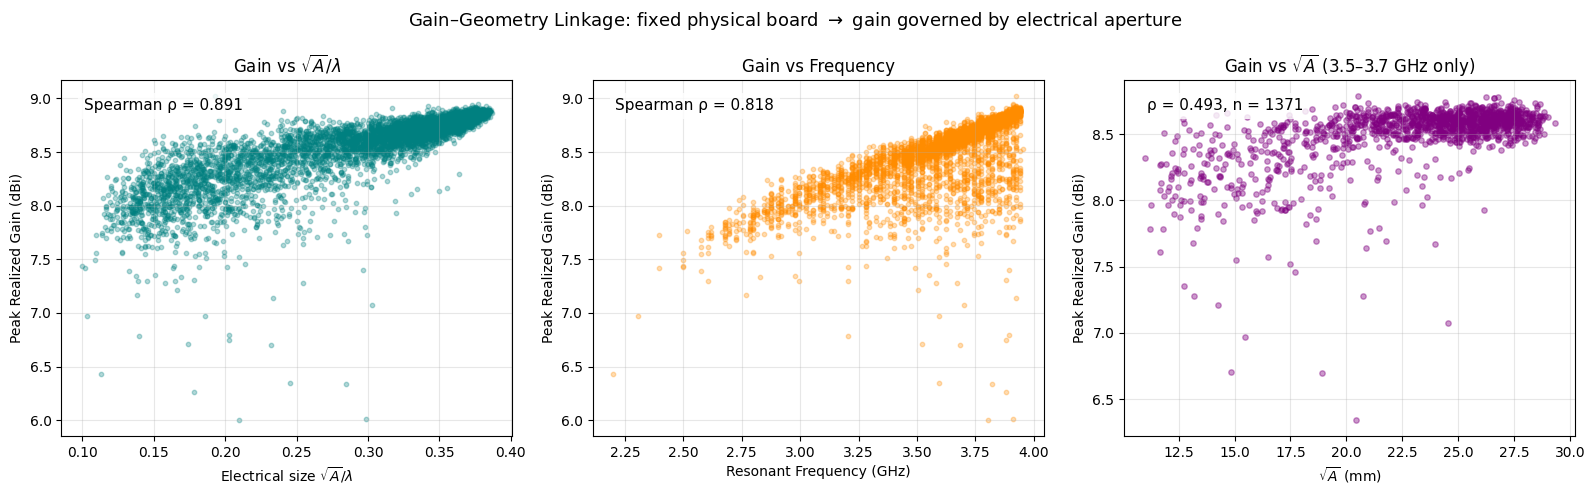

Saved to /content/drive/MyDrive/antenna_gnn/artifacts/gain_geometry_corr.csv and /content/drive/MyDrive/antenna_gnn/figures/gain_geometry_linkage.png


In [9]:
from scipy.stats import spearmanr

# ── Load path-length CSV and inspect columns ──
df_path_full = pd.read_csv(f'{DATA_ROOT}/artifacts/path_length_data_25x25.csv')
print(f"path_length_data_25x25.csv columns: {list(df_path_full.columns)}")
print(f"  rows: {len(df_path_full)}")

# ── FIX 1: Reconstruct test_idx for the CSV ──
# Chunk 10's Cell 9 iterated test_indices_25 in order, keeping rows where:
#   bool(data.is_functioning) AND extract_resonant_freq(raw y) is not None.
# We reproduce that filter here to assign the correct test index to each CSV row.

csv_test_idxs = []
for idx in tqdm(test_indices_25, desc="Reconstructing CSV index"):
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False)
    # is_functioning attribute (fallback to extraction)
    if hasattr(data, 'is_functioning'):
        is_func = bool(data.is_functioning)
    else:
        is_func = extract_resonant_freq(data.y.squeeze(0).cpu().numpy(), freq_axis) is not None
    # Must also pass extraction (Chunk 10 skipped is_func=True but extraction=None)
    if is_func:
        raw_s11 = data.y.squeeze(0).cpu().numpy()
        if extract_resonant_freq(raw_s11, freq_axis) is not None:
            csv_test_idxs.append(idx)

assert len(csv_test_idxs) == len(df_path_full), \
    f"Index reconstruction failed: got {len(csv_test_idxs)} vs CSV {len(df_path_full)}"
df_path_full['test_idx'] = csv_test_idxs
print(f"Assigned test_idx to CSV. Range: {min(csv_test_idxs)}-{max(csv_test_idxs)}")

# ── Merge on test index ──
# df_meta has 'idx' which is the test index
func_meta = df_meta[df_meta['is_functioning'] == True].copy()
func_meta = func_meta.rename(columns={'idx': 'test_idx'})

n_before = len(func_meta)
func_meta = func_meta.merge(
    df_path_full[['test_idx', 'L_max_mm', 'L_p90_mm', 'L_median_mm', 'L_sqrt_area_mm']],
    on='test_idx', how='inner'
)
n_after = len(func_meta)
print(f"Merged: {n_before} functioning -> {n_after} with path data "
      f"({n_before - n_after} dropped outside intersection)")

# ── FIX 3: Compute electrical size ──
# elec_size = sqrt(A) / lambda = L_sqrt_area_mm * f_GHz / 299.79
func_meta['elec_size'] = func_meta['L_sqrt_area_mm'] * func_meta['res_freq_ghz'] / 299.79

# ── Spearman correlations: gain vs each metric ──
corr_metrics = ['elec_size', 'res_freq_ghz', 'L_sqrt_area_mm',
                'L_p90_mm', 'L_median_mm', 'L_max_mm']
corr_rows = []
gains = func_meta['res_gains']

for metric in corr_metrics:
    vals = func_meta[metric]
    mask = vals.notna() & gains.notna()
    if mask.sum() > 10:
        rho, p = spearmanr(vals[mask], gains[mask])
    else:
        rho, p = float('nan'), float('nan')
    corr_rows.append({'metric': metric, 'spearman_rho': rho, 'p_value': p,
                      'target': 'res_gains'})

# ── FIX 4: Radiation efficiency correlations ──
eff_metrics = ['elec_size', 'res_freq_ghz']
effs = func_meta['res_effs']
for metric in eff_metrics:
    vals = func_meta[metric]
    mask = vals.notna() & effs.notna()
    if mask.sum() > 10:
        rho, p = spearmanr(vals[mask], effs[mask])
    else:
        rho, p = float('nan'), float('nan')
    corr_rows.append({'metric': metric, 'spearman_rho': rho, 'p_value': p,
                      'target': 'res_effs'})

corr_df = pd.DataFrame(corr_rows)
csv_path = f'{DATA_ROOT}/artifacts/gain_geometry_corr.csv'
corr_df.to_csv(csv_path, index=False)

# Print gain correlations ranked by |rho|
gain_corr = corr_df[corr_df['target'] == 'res_gains'].sort_values(
    'spearman_rho', ascending=False, key=abs)
print("\n=== Gain-Geometry Correlations (Spearman, target=res_gains) ===")
print(f"{'Metric':<20} {'rho':>8} {'p':>12}")
print("-" * 42)
for _, row in gain_corr.iterrows():
    print(f"{row['metric']:<20} {row['spearman_rho']:>8.4f} {row['p_value']:>12.2e}")

# Print efficiency correlations
eff_corr = corr_df[corr_df['target'] == 'res_effs']
n_valid_effs = effs.notna().sum()
print(f"\n=== Efficiency Correlations (Spearman, target=res_effs, n={n_valid_effs}) ===")
print(f"{'Metric':<20} {'rho':>8} {'p':>12}")
print("-" * 42)
for _, row in eff_corr.iterrows():
    print(f"{row['metric']:<20} {row['spearman_rho']:>8.4f} {row['p_value']:>12.2e}")

# ── FIX 3c: Frequency-stratified check (3.5-3.7 GHz) ──
band_mask = ((func_meta['res_freq_ghz'] >= 3.5) &
             (func_meta['res_freq_ghz'] <= 3.7) &
             func_meta['L_sqrt_area_mm'].notna() &
             func_meta['res_gains'].notna())
n_band = band_mask.sum()
if n_band > 10:
    rho_band, p_band = spearmanr(
        func_meta.loc[band_mask, 'L_sqrt_area_mm'],
        func_meta.loc[band_mask, 'res_gains'])
    print(f"\n=== Fixed-frequency check (3.5-3.7 GHz, n={n_band}) ===")
    print(f"  Spearman rho(gain, sqrt_area) = {rho_band:.4f}  (p = {p_band:.2e})")
else:
    rho_band = float('nan')
    print(f"\n=== Fixed-frequency check: only {n_band} samples in 3.5-3.7 GHz ===")

# ── FIX 2 & 3d: 1x3 figure with per-panel masks ──
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: gain vs elec_size
x1 = func_meta['elec_size']
y1 = func_meta['res_gains']
mask1 = x1.notna() & y1.notna()
rho_es = gain_corr[gain_corr['metric'] == 'elec_size']['spearman_rho'].values[0]
ax1.scatter(x1[mask1], y1[mask1], alpha=0.3, s=10, color='teal')
ax1.set_xlabel(r'Electrical size $\sqrt{A}/\lambda$')
ax1.set_ylabel('Peak Realized Gain (dBi)')
ax1.set_title(r'Gain vs $\sqrt{A}/\lambda$')
ax1.text(0.05, 0.95, f'Spearman ρ = {rho_es:.3f}', transform=ax1.transAxes,
         fontsize=11, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax1.grid(True, alpha=0.3)

# Panel 2: gain vs res_freq_ghz
x2 = func_meta['res_freq_ghz']
mask2 = x2.notna() & y1.notna()
rho_fq = gain_corr[gain_corr['metric'] == 'res_freq_ghz']['spearman_rho'].values[0]
ax2.scatter(x2[mask2], y1[mask2], alpha=0.3, s=10, color='darkorange')
ax2.set_xlabel('Resonant Frequency (GHz)')
ax2.set_ylabel('Peak Realized Gain (dBi)')
ax2.set_title('Gain vs Frequency')
ax2.text(0.05, 0.95, f'Spearman ρ = {rho_fq:.3f}', transform=ax2.transAxes,
         fontsize=11, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax2.grid(True, alpha=0.3)

# Panel 3: gain vs L_sqrt_area_mm within 3.5-3.7 GHz
x3 = func_meta.loc[band_mask, 'L_sqrt_area_mm']
y3 = func_meta.loc[band_mask, 'res_gains']
mask3 = x3.notna() & y3.notna()
ax3.scatter(x3[mask3], y3[mask3], alpha=0.4, s=15, color='purple')
ax3.set_xlabel(r'$\sqrt{A}$ (mm)')
ax3.set_ylabel('Peak Realized Gain (dBi)')
ax3.set_title(r'Gain vs $\sqrt{A}$ (3.5–3.7 GHz only)')
rho_txt = f'ρ = {rho_band:.3f}, n = {n_band}' if not np.isnan(rho_band) else f'n = {n_band} (too few)'
ax3.text(0.05, 0.95, rho_txt, transform=ax3.transAxes,
         fontsize=11, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax3.grid(True, alpha=0.3)

fig.suptitle(r'Gain–Geometry Linkage: fixed physical board $\rightarrow$ gain governed by electrical aperture',
             fontsize=13)
plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/gain_geometry_linkage.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {csv_path} and {fig_path}")


---
## Cell 15 — Radiation Pattern Data Discovery
Diagnostic cell: inspects the raw .mat file structure to determine whether
angular radiation pattern data exists for downstream analysis.


In [18]:
import scipy.io as sio

# Load one raw .mat file from 25x25 dataset
mat_path = files_25[test_indices_25[0]]
mat = sio.loadmat(mat_path)

print("=== Raw .mat file keys ===")
print(f"File: {os.path.basename(mat_path)}\n")

pattern_key = None
for key in sorted(mat.keys()):
    if key.startswith('__'):
        continue
    val = mat[key]
    shape = val.shape if hasattr(val, 'shape') else 'scalar'
    dtype = val.dtype if hasattr(val, 'dtype') else type(val).__name__
    print(f"  {key:<20s}  shape={str(shape):<16s}  dtype={dtype}")

    # Check for angular radiation pattern: 2D array with angle-like dimension
    if hasattr(val, 'shape') and len(val.shape) >= 2:
        for dim_size in val.shape:
            if dim_size in (181, 361, 91, 37, 73):  # common angular discretizations
                pattern_key = key

if pattern_key is not None:
    print(f"\nPATTERN DATA PRESENT: {pattern_key}")
else:
    print("\nPATTERN DATA ABSENT — only scalar gain available; full "
          "pattern-vs-path analysis requires re-simulation and is out of "
          "scope for this paper.")


=== Raw .mat file keys ===
File: Antenna_Seed_78455.mat

  S11_dB                shape=(1, 201)          dtype=float64
  VSWR_full             shape=(1, 201)          dtype=float64
  patch_pattern         shape=(25, 25)          dtype=uint8
  res_effs              shape=(1, 0)            dtype=uint8
  res_gains             shape=(1, 0)            dtype=uint8
  resonant_bws          shape=(1, 0)            dtype=uint8
  resonant_freqs        shape=(1, 0)            dtype=uint8
  resonant_vswrs        shape=(1, 0)            dtype=uint8

PATTERN DATA ABSENT — only scalar gain available; full pattern-vs-path analysis requires re-simulation and is out of scope for this paper.


---
## Regression Guards


In [19]:
# Store Cell 13 source text for regression guard
import json as _json
_nb = _json.load(open(f'{REPO_ROOT}/notebooks/chunk11_latent_analysis.ipynb', encoding='utf-8'))
nb_cells_13_source = ''.join(_nb['cells'][13].get('source', []))
del _nb


In [20]:
import inspect

# Guard 1: df_meta contains required columns
required_cols = ['idx', 'res_gains', 'res_freq_ghz', 'res_effs']
for col in required_cols:
    assert col in df_meta.columns, f"REGRESSION: df_meta missing column '{col}'"
    print(f"[Guard 1] df_meta has '{col}': PASS")

# Guard 2: UMAP cell (Cell 13) was not modified
src_cell13_lines = nb_cells_13_source
assert 'n_neighbors=30' in src_cell13_lines, "REGRESSION: UMAP n_neighbors changed"
assert 'min_dist=0.1' in src_cell13_lines, "REGRESSION: UMAP min_dist changed"
print("[Guard 2] UMAP Cell 13 has n_neighbors=30, min_dist=0.1: PASS")

# Guard 3: func_meta has > 5000 rows with non-null L_sqrt_area_mm
n_valid_sqrt = func_meta['L_sqrt_area_mm'].notna().sum()
assert n_valid_sqrt > 5000, f"REGRESSION: func_meta has only {n_valid_sqrt} non-null L_sqrt_area_mm rows"
print(f"[Guard 3] func_meta has {n_valid_sqrt} non-null L_sqrt_area_mm rows (> 5000): PASS")

# Guard 4: elec_size correlation is not NaN
es_rho = corr_df.loc[corr_df['metric'] == 'elec_size', 'spearman_rho'].values
assert len(es_rho) > 0 and not np.isnan(es_rho[0]), "REGRESSION: elec_size correlation is NaN"
print(f"[Guard 4] elec_size Spearman rho = {es_rho[0]:.4f} (not NaN): PASS")

print("\nAll chunk11 regression guards PASSED.")


[Guard 1] df_meta has 'idx': PASS
[Guard 1] df_meta has 'res_gains': PASS
[Guard 1] df_meta has 'res_freq_ghz': PASS
[Guard 1] df_meta has 'res_effs': PASS
[Guard 2] UMAP Cell 13 has n_neighbors=30, min_dist=0.1: PASS
[Guard 3] func_meta has 5485 non-null L_sqrt_area_mm rows (> 5000): PASS
[Guard 4] elec_size Spearman rho = 0.8912 (not NaN): PASS

All chunk11 regression guards PASSED.
